# Backtester V2.2 configurable — hasta 12 valores, ventanas seleccionables y fecha final

Esta versión permite fijar la fecha desde la que se cuentan hacia atrás todas las ventanas temporales. El resto de la estrategia, sus reglas de entrada y salida y sus gráficos se mantienen como en la versión 2.1.

## Uso

1. En la celda **CONFIGURACIÓN**, deja sin `#` los activos que quieras ejecutar y comenta los demás.
2. Escribe el ticker de Yahoo Finance y el capital que quieras asignarle.
3. Activa de la misma manera las ventanas temporales deseadas.
4. Configura `FECHA_FIN_VENTANA`: usa `None` o `'HOY'` para llegar hasta la fecha actual, o una fecha como `'2026-01-01'` para terminar ese día.
5. Ejecuta todas las celdas.

Si la fecha elegida no es una sesión bursátil (fin de semana o festivo), se emplea automáticamente la última sesión común anterior disponible para todos los activos.

Ejemplos de tickers: `META`, `SHOP`, `ITX.MC`, `BMW.DE`, `7203.T`, `MC.PA`, `ASML.AS`.

Los precios se normalizan a 100 para representar conjuntamente cotizaciones en dólares, euros o yenes. En el gráfico final, cada activo y el total parten de **0 %**, por lo que sus resultados son directamente comparables aunque tengan distintos capitales iniciales.

El cálculo usa precios ajustados por dividendos de forma predeterminada e incluye el deslizamiento configurado. No incluye comisiones, impuestos, intereses del efectivo ni costes/disponibilidad del préstamo para posiciones cortas.

## Conclusión sobre franjas y regímenes de mercado

Este algoritmo **no funciona igual en todos los regímenes**. La distribución 50/50 permite que la mitad LONG y la mitad SHORT operen en paralelo, pero no garantiza que sus resultados se compensen. Ambos lados pueden perder a la vez cuando hay falsas rupturas, gaps o cambios frecuentes de dirección.

- **LONG RSI + Bollinger:** tiende a funcionar mejor después de caídas exageradas seguidas de rebote. Puede fallar en tendencias bajistas persistentes.
- **LONG por ruptura:** necesita una tendencia alcista sostenida y confirmada por volumen. Sufre en mercados laterales o con rupturas alcistas falsas.
- **SHORT RSI:** funciona mejor cuando la sobrecompra termina revirtiendo hacia la media. Es peligroso durante subidas fuertes y persistentes.
- **SHORT por ruptura:** necesita una tendencia bajista real y continuada. Puede acumular stops cuando interpreta simples correcciones dentro de un mercado alcista como el inicio de una caída.

### Evidencia observada: 06-09-2023 a 06-06-2024

Con META y SHOP, capital repartido al 50 % entre LONG y SHORT y una ventana de nueve meses, la cartera combinada obtuvo **-9,17 %**, frente a **+29,03 %** de Buy & Hold. La mitad LONG obtuvo aproximadamente **-1,72 %** y la mitad SHORT **-16,62 %**. META subió aproximadamente **+63,66 %** en Buy & Hold, un entorno especialmente adverso para vender rupturas bajistas.

En esa muestra, el LONG RSI + Bollinger y el SHORT RSI fueron rentables en conjunto, mientras que el LONG por ruptura sufrió falsas rupturas y el SHORT por ruptura perdió en sus siete operaciones. Además, los stops, el trailing ATR y el límite de 20 sesiones pueden impedir que el LONG capture por completo tendencias alcistas de varios meses, por lo que puede quedar muy por detrás de Buy & Hold.

**Interpretación:** el algoritmo parece más adecuado cuando existen movimientos y reversiones suficientemente definidos; es vulnerable en mercados laterales ruidosos y cuando opera contra una tendencia dominante. Esta conclusión es evidencia de una ventana concreta, no una garantía general. Debe comprobarse con muchas fechas finales, activos y periodos fuera de muestra antes de modificar filtros o parámetros.

## Valores interesantes para este momento de mercado

**Fecha del estudio:** 25-08-2026  
**Ventana:** últimos 6 meses hasta la última sesión disponible (21-08-2026 para ACS y 24-08-2026 para Nasdaq).  
**Configuración:** capital dividido al 50 % entre la subcartera LONG y la subcartera SHORT, con los parámetros actuales del backtester.

| Valor | Mercado | Combinada 50/50 | LONG | SHORT | Buy & Hold | Lectura del régimen |
|---|---|---:|---:|---:|---:|---|
| **ACS (`ACS.MC`)** | IBEX 35 | **+9,22 %** | +7,32 % | +11,12 % | +0,42 % | Candidato más equilibrado: ambos lados aportan y el drawdown fue aproximadamente -4,26 %. |
| **NVIDIA (`NVDA`)** | Nasdaq-100 | **+12,02 %** | +1,83 % | +22,22 % | +8,90 % | Encaje principalmente SHORT; el LONG aporta poco, pero ambos lados terminaron positivos. |
| **Amazon (`AMZN`)** | Nasdaq-100 | **+7,60 %** | **+41,46 %** | -26,25 % | +27,42 % | Candidato fundamentalmente LONG; el SHORT reduce de forma importante el resultado combinado. |

### Conclusión de la ventana

- **ACS** es el candidato más apropiado para aplicar el reparto 50/50 completo.
- **NVDA** ha funcionado mejor por el lado SHORT durante esta ventana.
- **AMZN** ha funcionado claramente mejor como estrategia exclusivamente LONG: +41,46 % frente a +27,42 % de Buy & Hold.

Estos valores se han seleccionado retrospectivamente entre una muestra amplia, por lo que existe sesgo de selección. El apartado describe el régimen observado en esta fecha y debe actualizarse al cambiar `FECHA_FIN_VENTANA`; no constituye una predicción ni una recomendación de compra o venta.

In [ ]:
# ========================= CONFIGURACIÓN GENERAL =========================
# Esta es la única sección que normalmente debe modificar el usuario.

# ACTIVOS contiene parejas formadas por el ticker de Yahoo Finance y el
# capital teórico que se asigna exclusivamente a ese valor. Para activar o
# desactivar un valor basta con quitar o añadir # al principio de su línea.
# Se admiten entre 1 y 12 valores activos.
ACTIVOS = [
    ('META',    5_000),
    ('SHOP',    5_000),
    # ('ITX.MC',  5_000),      # España
    # ('7203.T',  5_000),      # Toyota, Japón
    # ('7974.T',  5_000),      # Nintendo, Japón
    # ('BMW.DE',  5_000),      # Alemania
    # ('MC.PA',   5_000),      # LVMH, Francia
    # ('ASML.AS', 5_000),      # Países Bajos
    # ('AAPL',    5_000),
    # ('NVDA',    5_000),
    # ('MSFT',    5_000),
    ('AMZN',    5_000),
]

# Cada número representa la duración, en meses, de una ventana de backtest.
# Todas las ventanas terminarán en FECHA_FIN_VENTANA y contarán hacia atrás.
VENTANAS_MESES = [ 3,
    6,
    9
]
# Ejemplo para mostrar solo 3 y 9 meses:
# VENTANAS_MESES = [3, 9]

# NUEVO EN V2.2: extremo final común de todas las ventanas.
# - None o 'HOY': utiliza la fecha actual del ordenador.
# - Una fecha 'AAAA-MM-DD': fija el final histórico del estudio.
# Si el día no tiene cotización, se usará la última sesión común anterior.
FECHA_FIN_VENTANA = None
# FECHA_FIN_VENTANA = '2025-06-06'

# Parámetros de cálculo y gestión del riesgo. Se conservan sin cambios.
AJUSTAR_DIVIDENDOS = True
STOP_LONG = 0.07                 # Stop de una posición larga: 7 %.
STOP_SHORT = 0.07                # Stop de una posición corta: 7 %.
DESLIZAMIENTO_BPS = 5             # 5 pb por ejecución (0.05 %); ajuste conservador.
PERIODO_RUPTURA = 20             # Sesiones usadas para detectar una ruptura.
MULTIPLICADOR_VOLUMEN = 1.00     # Volumen mínimo frente a su media previa.
RUPTURA_ATR = 2.0                # Distancia del trailing stop en múltiplos ATR.
RUPTURA_MAX_SESIONES = 20        # Duración máxima de una operación por ruptura.
RUPTURA_RSI_SALIDA_LONG = 45     # Debilidad que cierra un LONG por ruptura.
# ========================================================================

In [2]:
# ==================== IMPORTACIÓN Y PREPARACIÓN DE DATOS ====================
# Librerías estándar: avisos, carpeta temporal y manejo de rutas.
import warnings
import tempfile
from pathlib import Path

# relativedelta resta meses naturales (no un número aproximado de días).
from dateutil.relativedelta import relativedelta

# Librerías de cálculo, tablas, gráficos y descarga de cotizaciones.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import yfinance as yf
from IPython import get_ipython
from IPython.display import display

# Se ocultan avisos no críticos para que la salida del cuaderno sea legible.
warnings.filterwarnings('ignore')

# yfinance guarda su caché de zonas horarias en la carpeta temporal del sistema.
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_backtester_v22_config_cache'))

# Activa los gráficos integrados solo cuando el código se ejecuta en Jupyter.
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

# ---------------------- Validación de la configuración ----------------------
# Estas comprobaciones detienen pronto el programa y muestran un mensaje claro
# si el usuario ha escrito una configuración imposible o ambigua.
if not 1 <= len(ACTIVOS) <= 12:
    raise ValueError('Debes activar entre 1 y 12 valores.')

# Se normalizan los tickers a mayúsculas y se crea un diccionario ticker-capital.
tickers = [str(t).strip().upper() for t, _ in ACTIVOS]
capitales = {str(t).strip().upper(): float(c) for t, c in ACTIVOS}
if len(set(tickers)) != len(tickers):
    raise ValueError('No puede haber tickers duplicados en ACTIVOS.')
if any(c <= 0 for c in capitales.values()):
    raise ValueError('Todos los capitales deben ser mayores que cero.')
if not VENTANAS_MESES or any(not isinstance(m, int) or m <= 0 for m in VENTANAS_MESES):
    raise ValueError('VENTANAS_MESES debe contener enteros positivos.')

# Se eliminan ventanas repetidas y se ordenan de menor a mayor.
VENTANAS_MESES = sorted(set(VENTANAS_MESES))

# ---------------------- Resolución de la fecha final V2.2 -------------------
# None y el texto HOY significan lo mismo: la fecha actual, sin hora.
if FECHA_FIN_VENTANA is None or str(FECHA_FIN_VENTANA).strip().upper() == 'HOY':
    fecha_fin_solicitada = pd.Timestamp.today().normalize()
else:
    try:
        fecha_fin_solicitada = pd.Timestamp(FECHA_FIN_VENTANA).normalize()
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "FECHA_FIN_VENTANA debe ser None, 'HOY' o una fecha válida 'AAAA-MM-DD'."
        ) from exc

# No se admiten fechas futuras porque todavía no existen cotizaciones para ellas.
hoy = pd.Timestamp.today().normalize()
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN_VENTANA no puede ser posterior a la fecha actual.')

# Se descargan cinco meses extra antes de la ventana mayor. Ese margen permite
# calcular RSI, Bollinger, EMA, ATR y medias sin perder el inicio del backtest.
max_meses = max(VENTANAS_MESES)
inicio_descarga = fecha_fin_solicitada - relativedelta(months=max_meses + 5)

datos_raw = {}
errores = []

# BUCLE DE DESCARGA: recorre una vez cada ticker activo, descarga sus velas
# diarias, homogeneiza columnas/fechas y guarda el DataFrame ya limpio.
for ticker in tickers:
    try:
        # yfinance interpreta end como límite exclusivo; se suma un día para
        # incluir FECHA_FIN_VENTANA cuando esta sea una sesión bursátil.
        d = yf.download(
            ticker,
            start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d',
            auto_adjust=AJUSTAR_DIVIDENDOS,
            progress=False,
            threads=False
        )

        # Algunas versiones de yfinance devuelven columnas multinivel incluso
        # al pedir un único ticker. Aquí se convierten en columnas sencillas.
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)

        # Solo se conservan los campos OHLCV que utiliza la estrategia.
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()

        # Se eliminan zona horaria y hora para comparar únicamente fechas.
        if getattr(d.index, 'tz', None) is not None:
            d.index = d.index.tz_localize(None)
        d.index = pd.to_datetime(d.index).normalize()
        d = d[~d.index.duplicated(keep='last')].sort_index()

        # Sesenta sesiones son el mínimo prudente para indicadores y backtest.
        if len(d) < 60:
            raise ValueError(f'solo se recibieron {len(d)} sesiones')
        datos_raw[ticker] = d
    except Exception as exc:
        # No se interrumpe el bucle: se recopilan todos los fallos para informar
        # juntos al usuario al terminar de intentar las descargas.
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error descargando datos:\n' + '\n'.join(errores))

# Cada mercado puede tener festivos distintos. El mínimo de sus últimas fechas
# garantiza que todos los activos terminan en una sesión realmente compartida.
ultima_fecha_comun = min(d.index.max() for d in datos_raw.values())

print('Valores activos:', ', '.join(f'{t} ({capitales[t]:,.2f})' for t in tickers))
print('Ventanas activas:', ', '.join(f'{m} meses' for m in VENTANAS_MESES))
print('Fecha final solicitada:', fecha_fin_solicitada.date())
print('Última sesión común utilizada:', ultima_fecha_comun.date())

Valores activos: META (5,000.00), SHOP (5,000.00)
Ventanas activas: 3 meses, 6 meses, 9 meses
Fecha final solicitada: 2026-08-25
Última sesión común utilizada: 2026-08-24


In [3]:
# ========================= CÁLCULO DE INDICADORES =========================
def preparar_senales(df):
    """Añade al histórico todos los indicadores y señales de la estrategia."""
    d = df.copy()

    # RSI de 14 sesiones: separa variaciones positivas y negativas y compara
    # sus medias. Valores bajos sugieren sobreventa y altos, sobrecompra.
    delta = d['Close'].diff()
    subida = delta.clip(lower=0)
    bajada = -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)

    # Bandas de Bollinger: media de 20 sesiones más/menos dos desviaciones.
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desviacion = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desviacion

    # EMA10: media exponencial que da más peso a cierres recientes.
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()

    # ATR14: mide volatilidad mediante el mayor de tres rangos diarios posibles.
    cierre_previo = d['Close'].shift(1)
    rangos_reales = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - cierre_previo).abs(),
        (d['Low'] - cierre_previo).abs()
    ], axis=1)
    tr = rangos_reales.max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()

    # Señales LONG: se entra por sobreventa y se sale al normalizarse precio/RSI.
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])

    # Las referencias de ruptura se desplazan una sesión para evitar usar datos
    # del propio día que produce la señal (evita sesgo de anticipación).
    d['MAXIMO_20_PREV'] = d['High'].rolling(PERIODO_RUPTURA).max().shift(1)
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)

    # LONG de momentum: ruptura de máximos previos confirmada por volumen.
    d['LONG_RUPTURA'] = (
        (d['Close'] > d['MAXIMO_20_PREV'])
        & (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )

    # Señales SHORT: sobrecompra por RSI o ruptura de mínimos con volumen.
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (
        (d['Close'] < d['MINIMO_20_PREV'])
        & (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )
    return d


# COMPRENSIÓN POR TICKER: ejecuta la función anterior para cada activo y limita
# sus datos a la última sesión común, de modo que todos sean comparables.
datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}

In [4]:
# ================= MOTOR DE BACKTEST PARA UN ACTIVO =================
def ejecutar_v22(ticker, fecha_inicio, capital_inicial, lado_permitido='AMBOS'):
    """Simula un ticker entre fecha_inicio y la fecha final común.

    Las señales se calculan tras el cierre y las órdenes se ejecutan en la
    apertura siguiente. Los stops quedan activos durante la sesión y los
    gaps se rellenan a la apertura, nunca a un precio ya atravesado.
    """
    d = datos[ticker]
    fechas = d.index[(d.index >= fecha_inicio) & (d.index <= ultima_fecha_comun)]
    if len(fechas) < 2:
        raise ValueError(f'{ticker}: datos insuficientes para la ventana solicitada.')

    # Estado de la simulación. posicion vale None cuando no hay operación.
    capital = float(capital_inicial)
    posicion = None
    operaciones = []
    equity = []
    minimo_desde_entrada = np.inf
    maximo_desde_entrada = -np.inf
    trailing = np.inf
    sesiones = 0
    deslizamiento = DESLIZAMIENTO_BPS / 10_000

    def precio_con_deslizamiento(precio, lado):
        """Empeora el precio teórico para aproximar spread y deslizamiento."""
        factor = 1 + deslizamiento if lado == 'COMPRA' else 1 - deslizamiento
        return float(precio) * factor

    def cerrar(fecha, salida, motivo):
        """Cierra la posición abierta y actualiza capital e historial."""
        nonlocal capital, posicion

        # Un LONG gana si sube; un SHORT gana si el precio baja.
        if posicion['Tipo'] == 'LONG':
            retorno = (salida - posicion['Precio entrada']) / posicion['Precio entrada']
        else:
            retorno = (posicion['Precio entrada'] - salida) / posicion['Precio entrada']

        # Se reinvierte el capital completo: el rendimiento es compuesto.
        capital *= 1 + retorno
        operaciones.append({
            **posicion,
            'Salida': fecha,
            'Precio salida': salida,
            'Rentabilidad %': retorno * 100,
            'Motivo': motivo
        })
        posicion = None

    # BUCLE PRINCIPAL DE SESIONES: avanza cronológicamente día a día. En cada
    # iteración primero gestiona una posición existente, después estudia una
    # nueva entrada y finalmente registra el valor diario de la cartera.
    for fecha in fechas:
        i = d.index.get_loc(fecha)
        fila = d.iloc[i]                    # Precios de la sesión ejecutada.
        senal = d.iloc[i - 1] if i > 0 else None  # Señal del cierre anterior.
        apertura, maximo, minimo, cierre = map(
            float, [fila['Open'], fila['High'], fila['Low'], fila['Close']]
        )
        estaba_abierta = posicion is not None

        # 1) SALIDAS CONOCIDAS EN LA APERTURA. Las decisiones tomadas tras el
        # cierre anterior se ejecutan antes de consultar High/Low de hoy.
        if posicion is not None and senal is not None:
            entrada = posicion['Precio entrada']

            if posicion['Tipo'] == 'LONG':
                if posicion['Sistema entrada'] != 'RUPTURA ALCISTA':
                    if bool(senal['LONG_EXIT']):
                        salida = precio_con_deslizamiento(apertura, 'VENTA')
                        cerrar(fecha, salida, 'SEÑAL SALIDA LONG')
                else:
                    # Espejo temporal del SHORT por ruptura: dos cierres
                    # bajo EMA10, debilidad de RSI o máximo de sesiones.
                    pierde_ema = (
                        i >= 2
                        and bool((d['Close'].iloc[i - 2:i] < d['EMA10'].iloc[i - 2:i]).all())
                    )
                    if pierde_ema:
                        salida = precio_con_deslizamiento(apertura, 'VENTA')
                        cerrar(fecha, salida, 'DOS CIERRES BAJO EMA10')
                    elif bool(senal['RSI'] < RUPTURA_RSI_SALIDA_LONG):
                        salida = precio_con_deslizamiento(apertura, 'VENTA')
                        cerrar(fecha, salida, f'RSI < {RUPTURA_RSI_SALIDA_LONG}')
                    elif sesiones >= RUPTURA_MAX_SESIONES:
                        salida = precio_con_deslizamiento(apertura, 'VENTA')
                        cerrar(fecha, salida, 'MÁXIMO 20 SESIONES')

            elif posicion['Sistema entrada'] != 'RUPTURA':
                if bool(senal['RSI'] < 50):
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'SEÑAL SALIDA SHORT')

            else:
                # Todas estas condiciones usan exclusivamente cierres ya
                # conocidos y, por tanto, se ejecutan en la apertura.
                recupera_ema = (
                    i >= 2
                    and bool((d['Close'].iloc[i - 2:i] > d['EMA10'].iloc[i - 2:i]).all())
                )
                if recupera_ema:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'DOS CIERRES SOBRE EMA10')
                elif bool(senal['RSI'] > 55):
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'RSI > 55')
                elif sesiones >= RUPTURA_MAX_SESIONES:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'MÁXIMO 20 SESIONES')

        # 2) STOPS QUE ESTABAN ACTIVOS AL ABRIR. Un gap que atraviesa el stop
        # se ejecuta a la apertura; si se toca después, se usa el nivel stop.
        if posicion is not None and estaba_abierta:
            entrada = posicion['Precio entrada']
            if posicion['Tipo'] == 'LONG':
                stop_activo = entrada * (1 - STOP_LONG)
                if posicion['Sistema entrada'] == 'RUPTURA ALCISTA':
                    stop_activo = max(stop_activo, trailing)
                if apertura <= stop_activo:
                    salida = precio_con_deslizamiento(apertura, 'VENTA')
                    motivo = 'STOP/TRAILING RUPTURA LONG - GAP' if posicion['Sistema entrada'] == 'RUPTURA ALCISTA' else 'STOP LOSS LONG - GAP'
                    cerrar(fecha, salida, motivo)
                elif minimo <= stop_activo:
                    salida = precio_con_deslizamiento(stop_activo, 'VENTA')
                    motivo = 'STOP/TRAILING RUPTURA LONG' if posicion['Sistema entrada'] == 'RUPTURA ALCISTA' else 'STOP LOSS LONG'
                    cerrar(fecha, salida, motivo)
            else:
                stop_activo = entrada * (1 + STOP_SHORT)
                if posicion['Sistema entrada'] == 'RUPTURA':
                    stop_activo = min(stop_activo, trailing)
                if apertura >= stop_activo:
                    salida = precio_con_deslizamiento(apertura, 'COMPRA')
                    cerrar(fecha, salida, 'STOP SHORT - GAP')
                elif maximo >= stop_activo:
                    salida = precio_con_deslizamiento(stop_activo, 'COMPRA')
                    motivo = 'STOP/TRAILING RUPTURA' if posicion['Sistema entrada'] == 'RUPTURA' else 'STOP LOSS SHORT'
                    cerrar(fecha, salida, motivo)

        # 3) GESTIÓN DE ENTRADAS. No se abre otra operación en la misma apertura
        # en la que se cerró una anterior, evitando dos decisiones simultáneas.
        if posicion is None and not estaba_abierta and senal is not None:
            if lado_permitido in ('LONG', 'AMBOS') and bool(senal['LONG_ENTRY']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'LONG',
                    'Sistema entrada': 'RSI + BOLLINGER',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'COMPRA')
                }
            elif lado_permitido in ('LONG', 'AMBOS') and bool(senal['LONG_RUPTURA']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'LONG',
                    'Sistema entrada': 'RUPTURA ALCISTA',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'COMPRA')
                }
            elif lado_permitido in ('SHORT', 'AMBOS') and bool(senal['SHORT_RUPTURA']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'SHORT',
                    'Sistema entrada': 'RUPTURA',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'VENTA')
                }
            elif lado_permitido in ('SHORT', 'AMBOS') and bool(senal['SHORT_RSI']):
                posicion = {
                    'Ticker': ticker, 'Tipo': 'SHORT',
                    'Sistema entrada': 'RSI > 70',
                    'Entrada': fecha, 'Precio entrada': precio_con_deslizamiento(apertura, 'VENTA')
                }

            # Inicializa las variables auxiliares de cualquier nueva posición.
            if posicion is not None:
                minimo_desde_entrada = posicion['Precio entrada']
                maximo_desde_entrada = posicion['Precio entrada']
                trailing = (
                    posicion['Precio entrada'] * (1 - STOP_LONG)
                    if posicion['Tipo'] == 'LONG'
                    else posicion['Precio entrada'] * (1 + STOP_SHORT)
                )
                sesiones = 0

                # La orden bracket queda activa tras ejecutarse la entrada.
                entrada = posicion['Precio entrada']
                stop_activo = entrada * (1 - STOP_LONG) if posicion['Tipo'] == 'LONG' else entrada * (1 + STOP_SHORT)
                toca_stop = minimo <= stop_activo if posicion['Tipo'] == 'LONG' else maximo >= stop_activo
                if toca_stop:
                    lado = 'VENTA' if posicion['Tipo'] == 'LONG' else 'COMPRA'
                    salida = precio_con_deslizamiento(stop_activo, lado)
                    cerrar(fecha, salida, 'STOP MISMA SESIÓN DE ENTRADA')

        # 4) ACTUALIZACIÓN AL CIERRE. El nuevo trailing utiliza solo datos ya
        # cerrados y no estará activo hasta la apertura de la sesión siguiente.
        if posicion is not None and posicion['Sistema entrada'] in ('RUPTURA', 'RUPTURA ALCISTA'):
            sesiones += 1
            if posicion['Tipo'] == 'LONG':
                maximo_desde_entrada = max(maximo_desde_entrada, maximo)
                if pd.notna(fila['ATR14']):
                    candidato = maximo_desde_entrada - RUPTURA_ATR * float(fila['ATR14'])
                    trailing = max(trailing, candidato)
            else:
                minimo_desde_entrada = min(minimo_desde_entrada, minimo)
                if pd.notna(fila['ATR14']):
                    candidato = minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14'])
                    trailing = min(trailing, candidato)

        # 5) VALORACIÓN DIARIA. Con posición abierta se añade la ganancia o
        # pérdida latente al capital; sin posición, el valor coincide con caja.
        valor = capital
        if posicion is not None:
            entrada = posicion['Precio entrada']
            if posicion['Tipo'] == 'LONG':
                retorno_abierto = (cierre - entrada) / entrada
            else:
                retorno_abierto = (entrada - cierre) / entrada
            valor = capital * (1 + retorno_abierto)
        equity.append({'Fecha': fecha, 'Equity': valor})

    # Si la ventana termina con una posición viva, se liquida al último cierre
    # para que todas las métricas correspondan exactamente al mismo intervalo.
    if posicion is not None:
        ultimo_cierre = float(d.loc[fechas[-1], 'Close'])
        lado = 'VENTA' if posicion['Tipo'] == 'LONG' else 'COMPRA'
        salida = precio_con_deslizamiento(ultimo_cierre, lado)
        cerrar(fechas[-1], salida, 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital

    # El drawdown es la peor caída porcentual desde un máximo previo de equity.
    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity'] / eq['Equity'].cummax() - 1).min() * 100

    return {
        'Ticker': ticker,
        'Capital inicial': capital_inicial,
        'Capital final': capital,
        'Rentabilidad %': (capital / capital_inicial - 1) * 100,
        'Drawdown máximo %': dd,
        'Operaciones': operaciones,
        'Equity': eq,
        'Fecha inicio': fechas[0],
        'Fecha fin': fechas[-1]
    }


def ejecutar_v22_50_50(ticker, fecha_inicio, capital_inicial):
    """Ejecuta LONG y SHORT en paralelo con la mitad del capital cada uno."""
    capital_long = float(capital_inicial) * 0.50
    capital_short = float(capital_inicial) - capital_long
    r_long = ejecutar_v22(ticker, fecha_inicio, capital_long, lado_permitido='LONG')
    r_short = ejecutar_v22(ticker, fecha_inicio, capital_short, lado_permitido='SHORT')

    equity = pd.concat([
        r_long['Equity']['Equity'].rename('LONG'),
        r_short['Equity']['Equity'].rename('SHORT')
    ], axis=1).sort_index().ffill().dropna()
    equity['Equity'] = equity['LONG'] + equity['SHORT']
    eq_total = equity[['Equity']]
    capital_final = r_long['Capital final'] + r_short['Capital final']
    dd = (eq_total['Equity'] / eq_total['Equity'].cummax() - 1).min() * 100
    operaciones = sorted(
        r_long['Operaciones'] + r_short['Operaciones'],
        key=lambda op: (op['Entrada'], op['Tipo'])
    )

    return {
        'Ticker': ticker,
        'Capital inicial': capital_inicial,
        'Capital final': capital_final,
        'Rentabilidad %': (capital_final / capital_inicial - 1) * 100,
        'Drawdown máximo %': dd,
        'Operaciones': operaciones,
        'Equity': eq_total,
        'Fecha inicio': eq_total.index[0],
        'Fecha fin': eq_total.index[-1],
        'Resultado LONG': r_long,
        'Resultado SHORT': r_short
    }

In [5]:
# ================= EJECUCIÓN DE TODAS LAS VENTANAS =================
resultados = {}  # Estructura anidada: resultados[meses][ticker].
filas = []       # Registros que después formarán la tabla comparativa.
filas_lados = [] # Desglose independiente de las carteras LONG y SHORT.

# BUCLE EXTERIOR: crea una simulación independiente por cada duración elegida.
# La fecha inicial se calcula hacia atrás desde la fecha final común de V2.2.
for meses in VENTANAS_MESES:
    fecha_objetivo = ultima_fecha_comun - relativedelta(months=meses)
    resultados[meses] = {}
    bh_finales = []
    long_finales = []
    short_finales = []
    entradas_estrategia = []
    salidas_estrategia = []

    # BUCLE INTERIOR: dentro de la ventana actual ejecuta todos los tickers con
    # su propio capital. Los activos no comparten dinero ni posiciones.
    for ticker in tickers:
        r = ejecutar_v22_50_50(ticker, fecha_objetivo, capitales[ticker])
        resultados[meses][ticker] = r
        ops = pd.DataFrame(r['Operaciones'])

        # Buy & Hold comparable: mismo capital, primera apertura y último
        # cierre de la ventana, incluyendo el mismo deslizamiento de ida/vuelta.
        d_bh = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        coste_bh = float(d_bh['Open'].iloc[0]) * (1 + DESLIZAMIENTO_BPS / 10_000)
        venta_bh = float(d_bh['Close'].iloc[-1]) * (1 - DESLIZAMIENTO_BPS / 10_000)
        rentabilidad_bh = (venta_bh / coste_bh - 1) * 100
        capital_final_bh = r['Capital inicial'] * (1 + rentabilidad_bh / 100)
        bh_finales.append(capital_final_bh)
        long_finales.append(r['Resultado LONG']['Capital final'])
        short_finales.append(r['Resultado SHORT']['Capital final'])

        primera_entrada = ops['Entrada'].min() if not ops.empty else pd.NaT
        ultima_salida = ops['Salida'].max() if not ops.empty else pd.NaT
        if pd.notna(primera_entrada):
            entradas_estrategia.append(primera_entrada)
        if pd.notna(ultima_salida):
            salidas_estrategia.append(ultima_salida)

        # Dos filas reales: cada lado parte de la mitad del capital y mantiene
        # sus propias operaciones, fechas, rentabilidad y drawdown.
        for lado, resultado_lado in (
            ('LONG', r['Resultado LONG']),
            ('SHORT', r['Resultado SHORT'])
        ):
            ops_lado = pd.DataFrame(resultado_lado['Operaciones'])
            filas_lados.append({
                'Ventana (meses)': meses,
                'Ticker': ticker,
                'Lado': lado,
                'Capital inicial': resultado_lado['Capital inicial'],
                'Capital final': resultado_lado['Capital final'],
                'Beneficio': resultado_lado['Capital final'] - resultado_lado['Capital inicial'],
                'Rentabilidad %': resultado_lado['Rentabilidad %'],
                'Drawdown máximo %': resultado_lado['Drawdown máximo %'],
                'Operaciones': len(ops_lado),
                'Primera entrada': ops_lado['Entrada'].min() if not ops_lado.empty else pd.NaT,
                'Última salida': ops_lado['Salida'].max() if not ops_lado.empty else pd.NaT
            })

        # Cada diccionario será una fila de resultados para activo y ventana.
        filas.append({
            'Ventana (meses)': meses,
            'Ticker': ticker,
            'Capital inicial': r['Capital inicial'],
            'Capital final': r['Capital final'],
            'Beneficio': r['Capital final'] - r['Capital inicial'],
            'Rentabilidad %': r['Rentabilidad %'],
            'Rentabilidad LONG 50%': r['Resultado LONG']['Rentabilidad %'],
            'Rentabilidad SHORT 50%': r['Resultado SHORT']['Rentabilidad %'],
            'Primera entrada': primera_entrada,
            'Última salida': ultima_salida,
            'Entrada B&H': r['Fecha inicio'],
            'Salida B&H': r['Fecha fin'],
            'Capital final B&H': capital_final_bh,
            'Rentabilidad B&H %': rentabilidad_bh,
            'Ventaja vs B&H (pp)': r['Rentabilidad %'] - rentabilidad_bh,
            'Drawdown máximo %': r['Drawdown máximo %'],
            'Operaciones': len(ops),
            'Acierto %': ops['Rentabilidad %'].gt(0).mean() * 100 if not ops.empty else 0
        })

    # Las curvas individuales se alinean por fecha y se suman para construir la
    # cartera. ffill conserva el último valor conocido cuando falta una sesión.
    curvas = [
        r['Equity']['Equity'].rename(ticker)
        for ticker, r in resultados[meses].items()
    ]
    total_eq = pd.concat(curvas, axis=1).sort_index().ffill().dropna().sum(axis=1)
    capital_total = sum(capitales.values())
    final_total = float(total_eq.iloc[-1])
    final_total_bh = float(sum(bh_finales))
    final_total_long = float(sum(long_finales))
    final_total_short = float(sum(short_finales))
    dd_total = (total_eq / total_eq.cummax() - 1).min() * 100
    rentabilidad_total = (final_total / capital_total - 1) * 100
    rentabilidad_total_bh = (final_total_bh / capital_total - 1) * 100

    # Resumen agregado de cada mitad de la cartera para esta ventana.
    for lado, clave in (('LONG', 'Resultado LONG'), ('SHORT', 'Resultado SHORT')):
        curvas_lado = [
            r[clave]['Equity']['Equity'].rename(ticker)
            for ticker, r in resultados[meses].items()
        ]
        total_lado_eq = pd.concat(curvas_lado, axis=1).sort_index().ffill().dropna().sum(axis=1)
        capital_lado_inicial = capital_total * 0.50
        capital_lado_final = float(total_lado_eq.iloc[-1])
        dd_lado = (total_lado_eq / total_lado_eq.cummax() - 1).min() * 100
        ops_lado_total = [
            op for r in resultados[meses].values() for op in r[clave]['Operaciones']
        ]
        filas_lados.append({
            'Ventana (meses)': meses,
            'Ticker': 'TOTAL CARTERA',
            'Lado': lado,
            'Capital inicial': capital_lado_inicial,
            'Capital final': capital_lado_final,
            'Beneficio': capital_lado_final - capital_lado_inicial,
            'Rentabilidad %': (capital_lado_final / capital_lado_inicial - 1) * 100,
            'Drawdown máximo %': dd_lado,
            'Operaciones': len(ops_lado_total),
            'Primera entrada': min((op['Entrada'] for op in ops_lado_total), default=pd.NaT),
            'Última salida': max((op['Salida'] for op in ops_lado_total), default=pd.NaT)
        })

    # Se añade una fila resumen ponderada por el capital real de cada activo.
    filas.append({
        'Ventana (meses)': meses,
        'Ticker': 'TOTAL CARTERA',
        'Capital inicial': capital_total,
        'Capital final': final_total,
        'Beneficio': final_total - capital_total,
        'Rentabilidad %': rentabilidad_total,
        'Rentabilidad LONG 50%': (final_total_long / (capital_total * 0.50) - 1) * 100,
        'Rentabilidad SHORT 50%': (final_total_short / (capital_total * 0.50) - 1) * 100,
        'Primera entrada': min(entradas_estrategia) if entradas_estrategia else pd.NaT,
        'Última salida': max(salidas_estrategia) if salidas_estrategia else pd.NaT,
        'Entrada B&H': min(r['Fecha inicio'] for r in resultados[meses].values()),
        'Salida B&H': max(r['Fecha fin'] for r in resultados[meses].values()),
        'Capital final B&H': final_total_bh,
        'Rentabilidad B&H %': rentabilidad_total_bh,
        'Ventaja vs B&H (pp)': rentabilidad_total - rentabilidad_total_bh,
        'Drawdown máximo %': dd_total,
        'Operaciones': sum(len(r['Operaciones']) for r in resultados[meses].values()),
        'Acierto %': np.nan
    })
    resultados[meses]['TOTAL CARTERA'] = {'Equity': total_eq.to_frame('Equity')}

# Conversión de registros en una tabla con índice doble: ventana y ticker.
tabla = pd.DataFrame(filas).set_index(['Ventana (meses)', 'Ticker'])
print('TABLA COMPARATIVA — LONG 50 % + SHORT 50 % FRENTE A BUY & HOLD')

# El formateo afecta solo a la presentación. La fila total se resalta para que
# pueda distinguirse rápidamente de los resultados de valores individuales.
display(tabla.style.format({
    'Capital inicial': '{:,.2f}',
    'Capital final': '{:,.2f}',
    'Beneficio': '{:+,.2f}',
    'Rentabilidad %': '{:+.2f}%',
    'Rentabilidad LONG 50%': '{:+.2f}%',
    'Rentabilidad SHORT 50%': '{:+.2f}%',
    'Primera entrada': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Última salida': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Entrada B&H': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Salida B&H': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Capital final B&H': '{:,.2f}',
    'Rentabilidad B&H %': '{:+.2f}%',
    'Ventaja vs B&H (pp)': '{:+.2f}',
    'Drawdown máximo %': '{:+.2f}%',
    'Acierto %': lambda x: '' if pd.isna(x) else f'{x:.1f}%'
}).apply(
    lambda fila: ['font-weight:bold;background-color:#fff3cd'] * len(fila)
    if fila.name[1] == 'TOTAL CARTERA' else [''] * len(fila),
    axis=1
))

# ------------------- Resumen separado de las dos subcarteras -------------------
tabla_lados = pd.DataFrame(filas_lados).set_index(['Ventana (meses)', 'Ticker', 'Lado'])
print('\nRESUMEN 50/50 — UNA FILA LONG Y OTRA SHORT')
display(tabla_lados.style.format({
    'Capital inicial': '{:,.2f}',
    'Capital final': '{:,.2f}',
    'Beneficio': '{:+,.2f}',
    'Rentabilidad %': '{:+.2f}%',
    'Drawdown máximo %': '{:+.2f}%',
    'Primera entrada': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Última salida': lambda x: '' if pd.isna(x) else pd.Timestamp(x).strftime('%Y-%m-%d')
}).apply(
    lambda fila: ['font-weight:bold;background-color:#fff3cd'] * len(fila)
    if fila.name[1] == 'TOTAL CARTERA' else [''] * len(fila),
    axis=1
))

# --------------------- Detalle simplificado de operaciones ---------------------
# Se muestra justo debajo del resumen. La numeración se reinicia para cada
# combinación de ventana y ticker.
detalle_operaciones = []
for meses in VENTANAS_MESES:
    for ticker in tickers:
        for numero, op in enumerate(resultados[meses][ticker]['Operaciones'], start=1):
            detalle_operaciones.append({
                'Ventana': f'{meses} meses',
                'Ticker': ticker,
                'Operación': numero,
                'Tipo de operación': f"{op['Tipo']} — {op['Sistema entrada']}",
                'Fec. entrada': op['Entrada'],
                'Fec. salida': op['Salida'],
                'Ganancia %': op['Rentabilidad %']
            })

tabla_operaciones = pd.DataFrame(detalle_operaciones)
print('\nDETALLE SIMPLIFICADO DE TODAS LAS OPERACIONES')
if tabla_operaciones.empty:
    print('No se generaron operaciones en las ventanas seleccionadas.')
else:
    display(
        tabla_operaciones.style
        .format({
            'Fec. entrada': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
            'Fec. salida': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
            'Ganancia %': '{:+.2f}%'
        })
        .map(
            lambda x: 'color:#087830;font-weight:bold' if x > 0
            else ('color:#b42318;font-weight:bold' if x < 0 else ''),
            subset=['Ganancia %']
        )
        .hide(axis='index')
    )

TABLA COMPARATIVA — LONG 50 % + SHORT 50 % FRENTE A BUY & HOLD



RESUMEN 50/50 — UNA FILA LONG Y OTRA SHORT



DETALLE SIMPLIFICADO DE TODAS LAS OPERACIONES


Ventana,Ticker,Operación,Tipo de operación,Fec. entrada,Fec. salida,Ganancia %
3 meses,META,1,SHORT — RUPTURA,2026-06-12,2026-06-15,-4.48%
3 meses,META,2,LONG — RUPTURA ALCISTA,2026-07-10,2026-07-17,-3.89%
3 meses,META,3,SHORT — RSI > 70,2026-07-16,2026-07-27,+10.25%
3 meses,META,4,LONG — RSI + BOLLINGER,2026-07-31,2026-08-24,+2.73%
3 meses,META,5,SHORT — RUPTURA,2026-07-31,2026-08-03,-7.05%
3 meses,SHOP,1,SHORT — RSI > 70,2026-06-02,2026-06-18,+10.42%
3 meses,SHOP,2,SHORT — RSI > 70,2026-07-10,2026-07-23,+7.26%
3 meses,SHOP,3,LONG — RUPTURA ALCISTA,2026-08-06,2026-08-20,+1.76%
3 meses,SHOP,4,SHORT — RSI > 70,2026-08-12,2026-08-24,+1.34%
6 meses,META,1,SHORT — RUPTURA,2026-03-16,2026-03-31,+11.35%


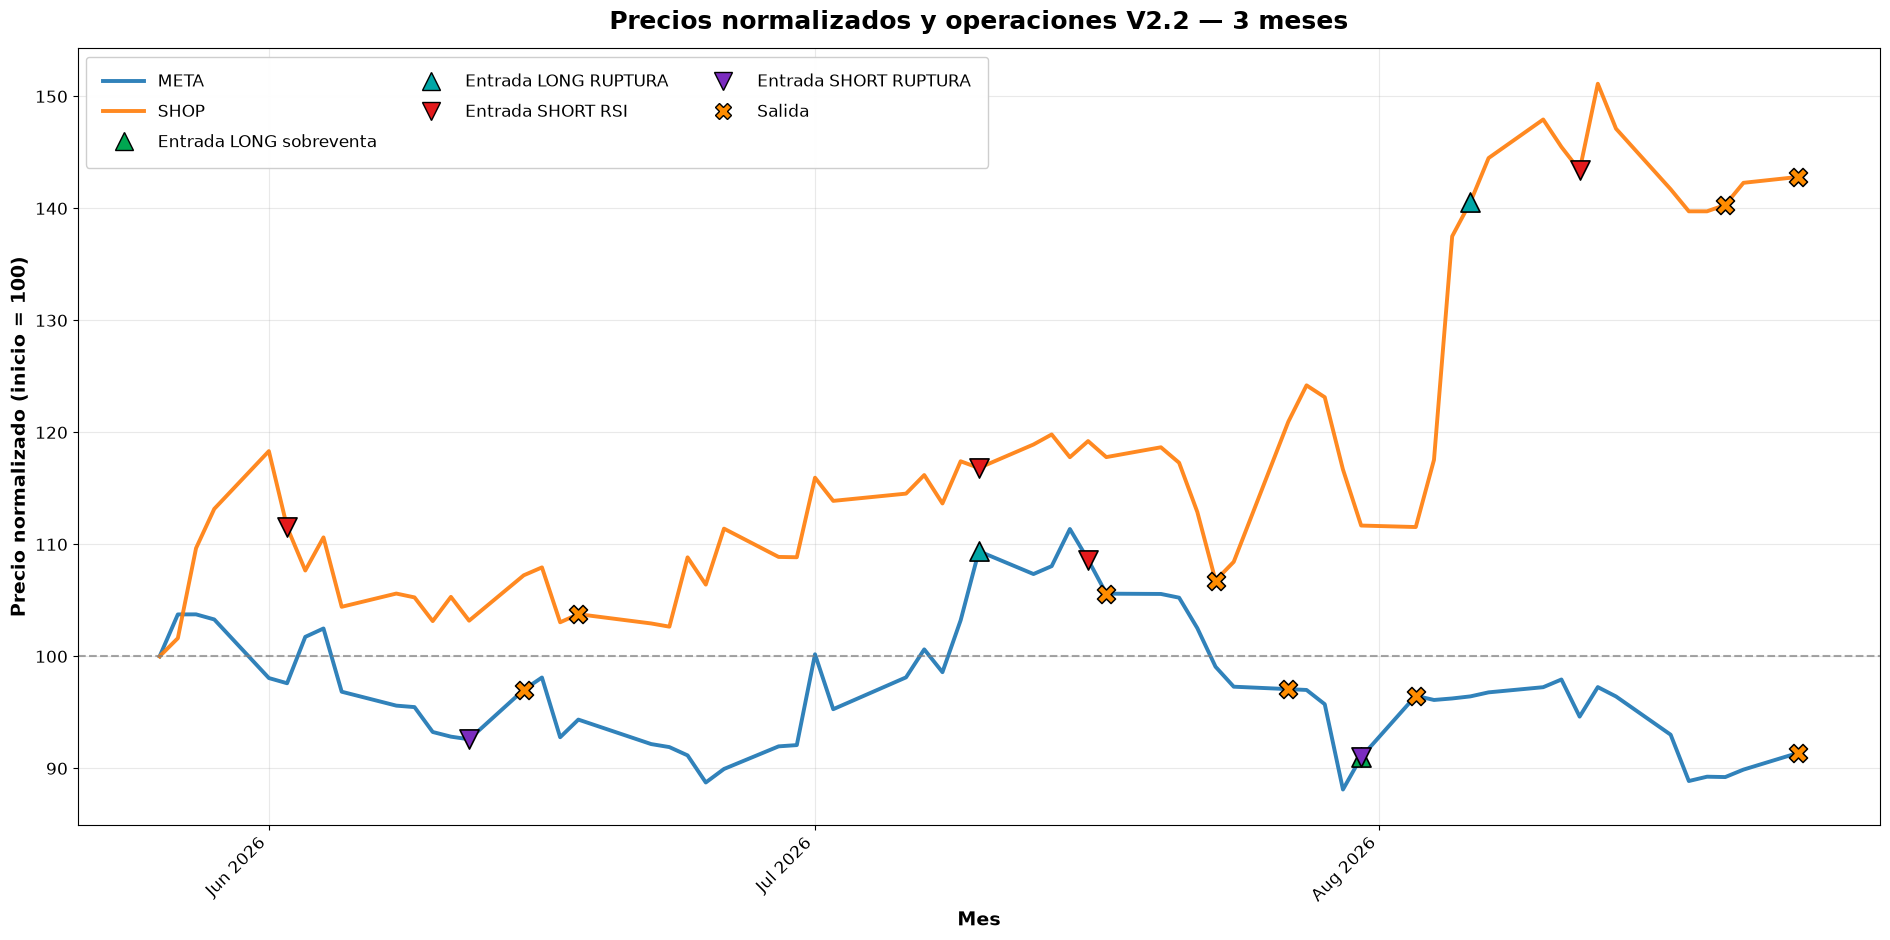

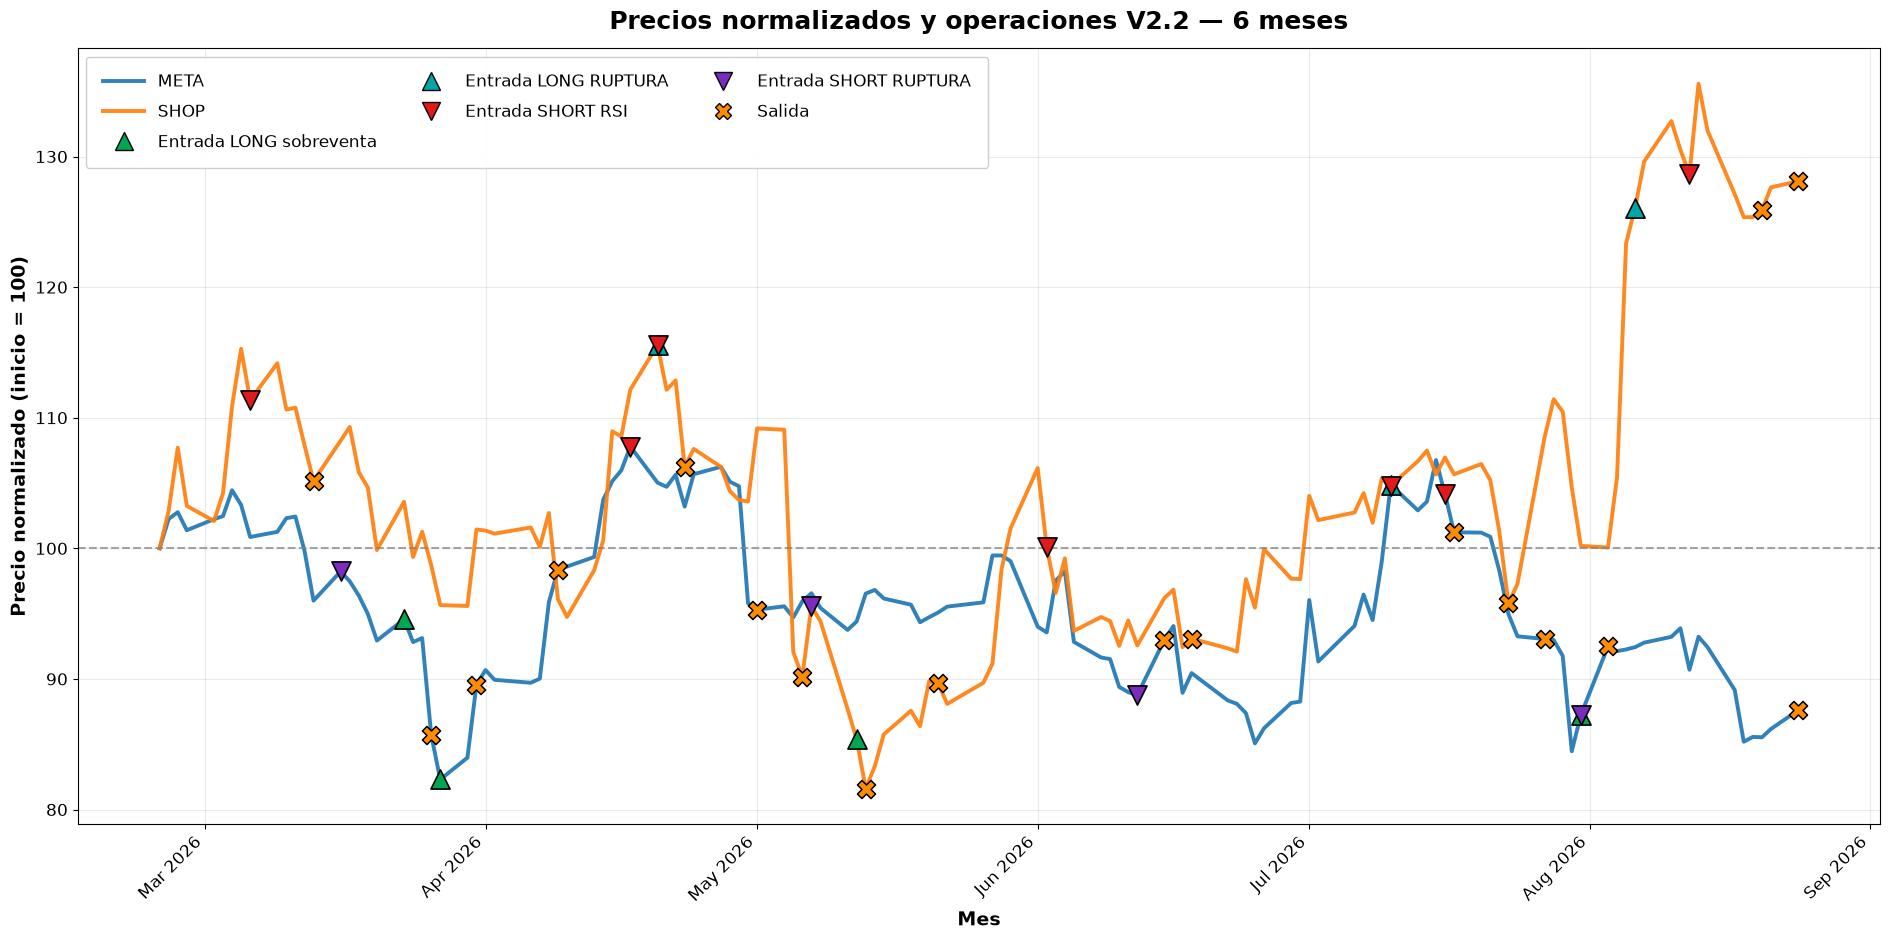

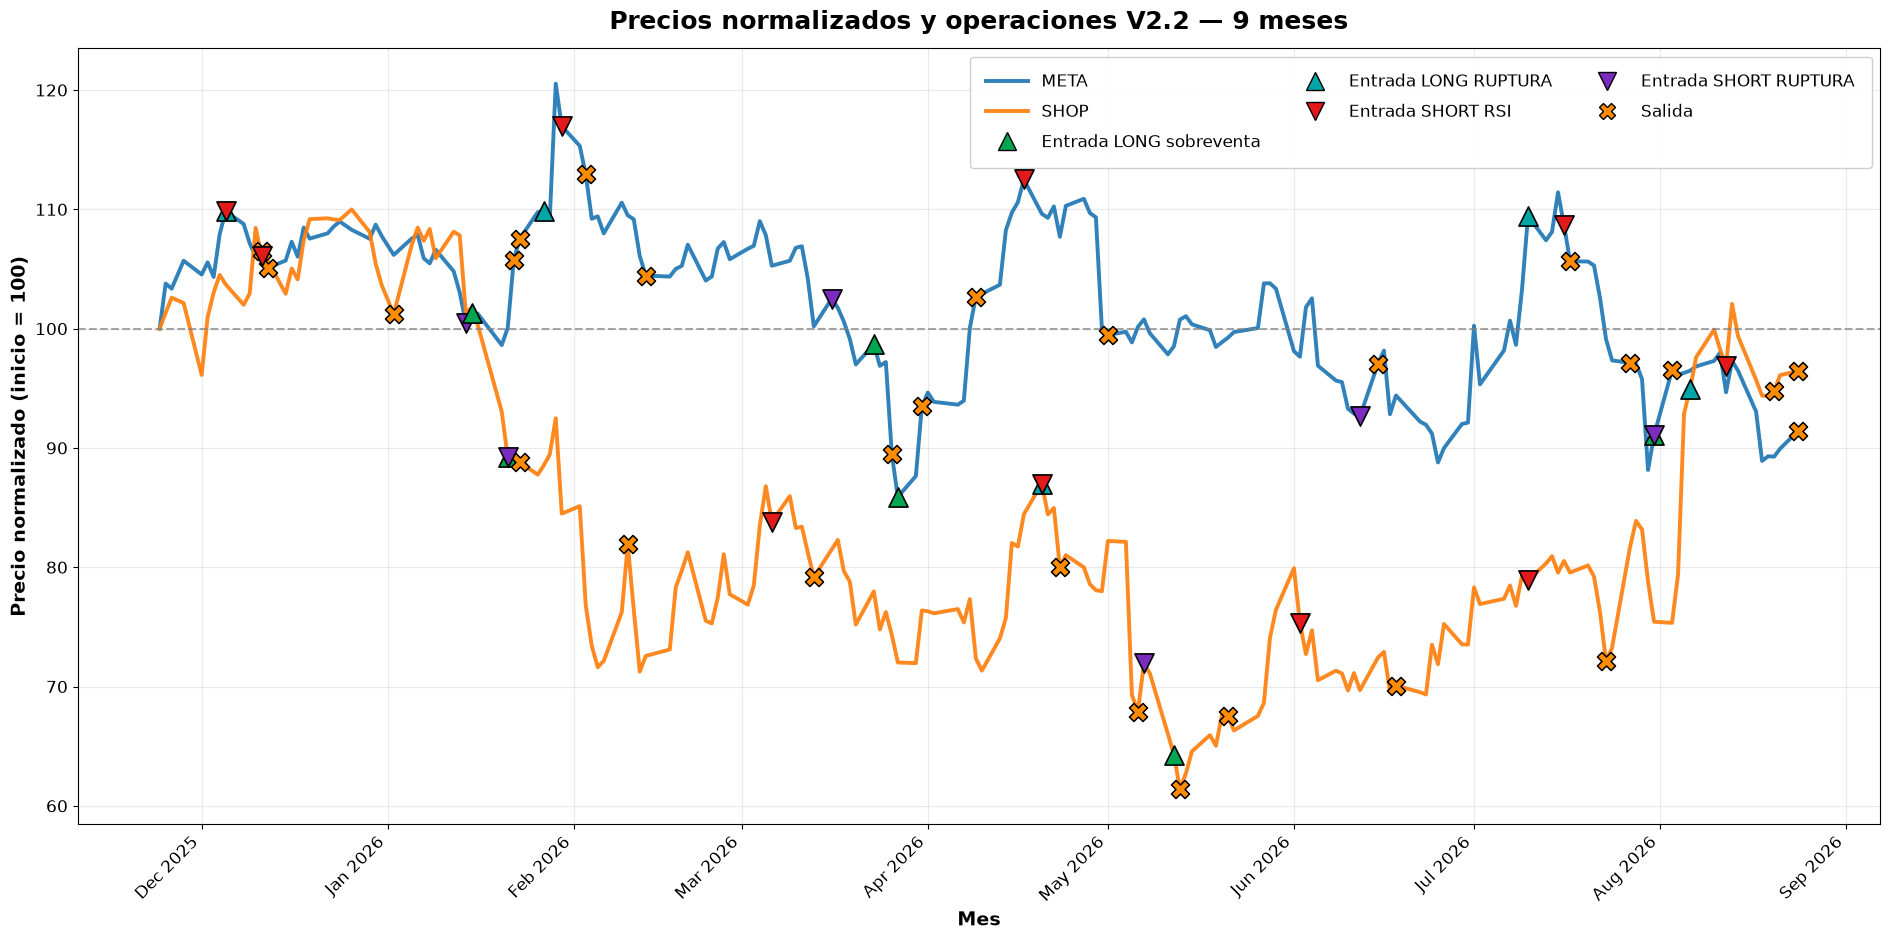

In [6]:
# ================= GRÁFICOS DE PRECIOS Y OPERACIONES =================
# A cada ticker se le asigna un color estable en todos los gráficos.
paleta = plt.get_cmap('tab10')
colores = {ticker: paleta(i % 10) for i, ticker in enumerate(tickers)}

# Los colores de operaciones tienen un significado fijo e independiente del activo.
COLOR_LONG = '#00A651'
COLOR_LONG_RUPTURA = '#00A6A6'
COLOR_SHORT_RSI = '#E31A1C'
COLOR_SHORT_RUPTURA = '#7B2CBF'
COLOR_SALIDA = '#FF8C00'

# BUCLE DE VENTANAS: produce y guarda una figura independiente por duración.
for meses in VENTANAS_MESES:
    fig, ax = plt.subplots(figsize=(19, 9.5))

    # BUCLE DE ACTIVOS: dibuja cada precio normalizado y sus operaciones. La
    # normalización a 100 permite comparar activos con monedas/precios distintos.
    for ticker in tickers:
        r = resultados[meses][ticker]
        d = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        normalizado = d['Close'] / d['Close'].iloc[0] * 100
        ax.plot(
            normalizado.index, normalizado, color=colores[ticker],
            lw=2.8, alpha=.92, label=ticker, zorder=2
        )

        # BUCLE DE OPERACIONES: coloca un marcador en cada entrada y salida.
        for op in r['Operaciones']:
            if op['Entrada'] in normalizado.index:
                y_entrada = float(normalizado.loc[op['Entrada']])
                if op['Sistema entrada'] == 'RUPTURA ALCISTA':
                    color_entrada, marcador = COLOR_LONG_RUPTURA, '^'
                elif op['Tipo'] == 'LONG':
                    color_entrada, marcador = COLOR_LONG, '^'
                elif op['Sistema entrada'] == 'RUPTURA':
                    color_entrada, marcador = COLOR_SHORT_RUPTURA, 'v'
                else:
                    color_entrada, marcador = COLOR_SHORT_RSI, 'v'
                ax.scatter(
                    op['Entrada'], y_entrada, color=color_entrada,
                    marker=marcador, s=190, edgecolor='black', linewidth=1.2,
                    zorder=7
                )

            if op['Salida'] in normalizado.index:
                y_salida = float(normalizado.loc[op['Salida']])
                ax.scatter(
                    op['Salida'], y_salida, color=COLOR_SALIDA,
                    marker='X', s=170, edgecolor='black', linewidth=1.1,
                    zorder=7
                )

    # Formato común de la figura: referencia 100, títulos, meses y cuadrícula.
    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=.7)
    ax.set_title(
        f'Precios normalizados y operaciones V2.2 — {meses} meses',
        fontsize=18, fontweight='bold', pad=14
    )
    ax.set_xlabel('Mes', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precio normalizado (inicio = 100)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.tick_params(axis='both', labelsize=12)

    # La leyenda combina las líneas de activos con los tipos de operación.
    # marcadores creados manualmente para explicar entradas y salidas.
    handles, labels = ax.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_LONG,
               markeredgecolor='black', markersize=13, label='Entrada LONG sobreventa'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_LONG_RUPTURA,
               markeredgecolor='black', markersize=13, label='Entrada LONG RUPTURA'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RSI,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RSI'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RUPTURA,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RUPTURA'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor=COLOR_SALIDA,
               markeredgecolor='black', markersize=12, label='Salida')
    ]
    ax.legend(
        handles=handles, loc='best', ncol=min(3, len(handles)),
        fontsize=12, framealpha=.96, borderpad=1.0,
        handlelength=2.5, labelspacing=.8
    )
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Se guarda un archivo distinto por ventana para no sobrescribir figuras.
    display(fig)
    plt.close(fig)

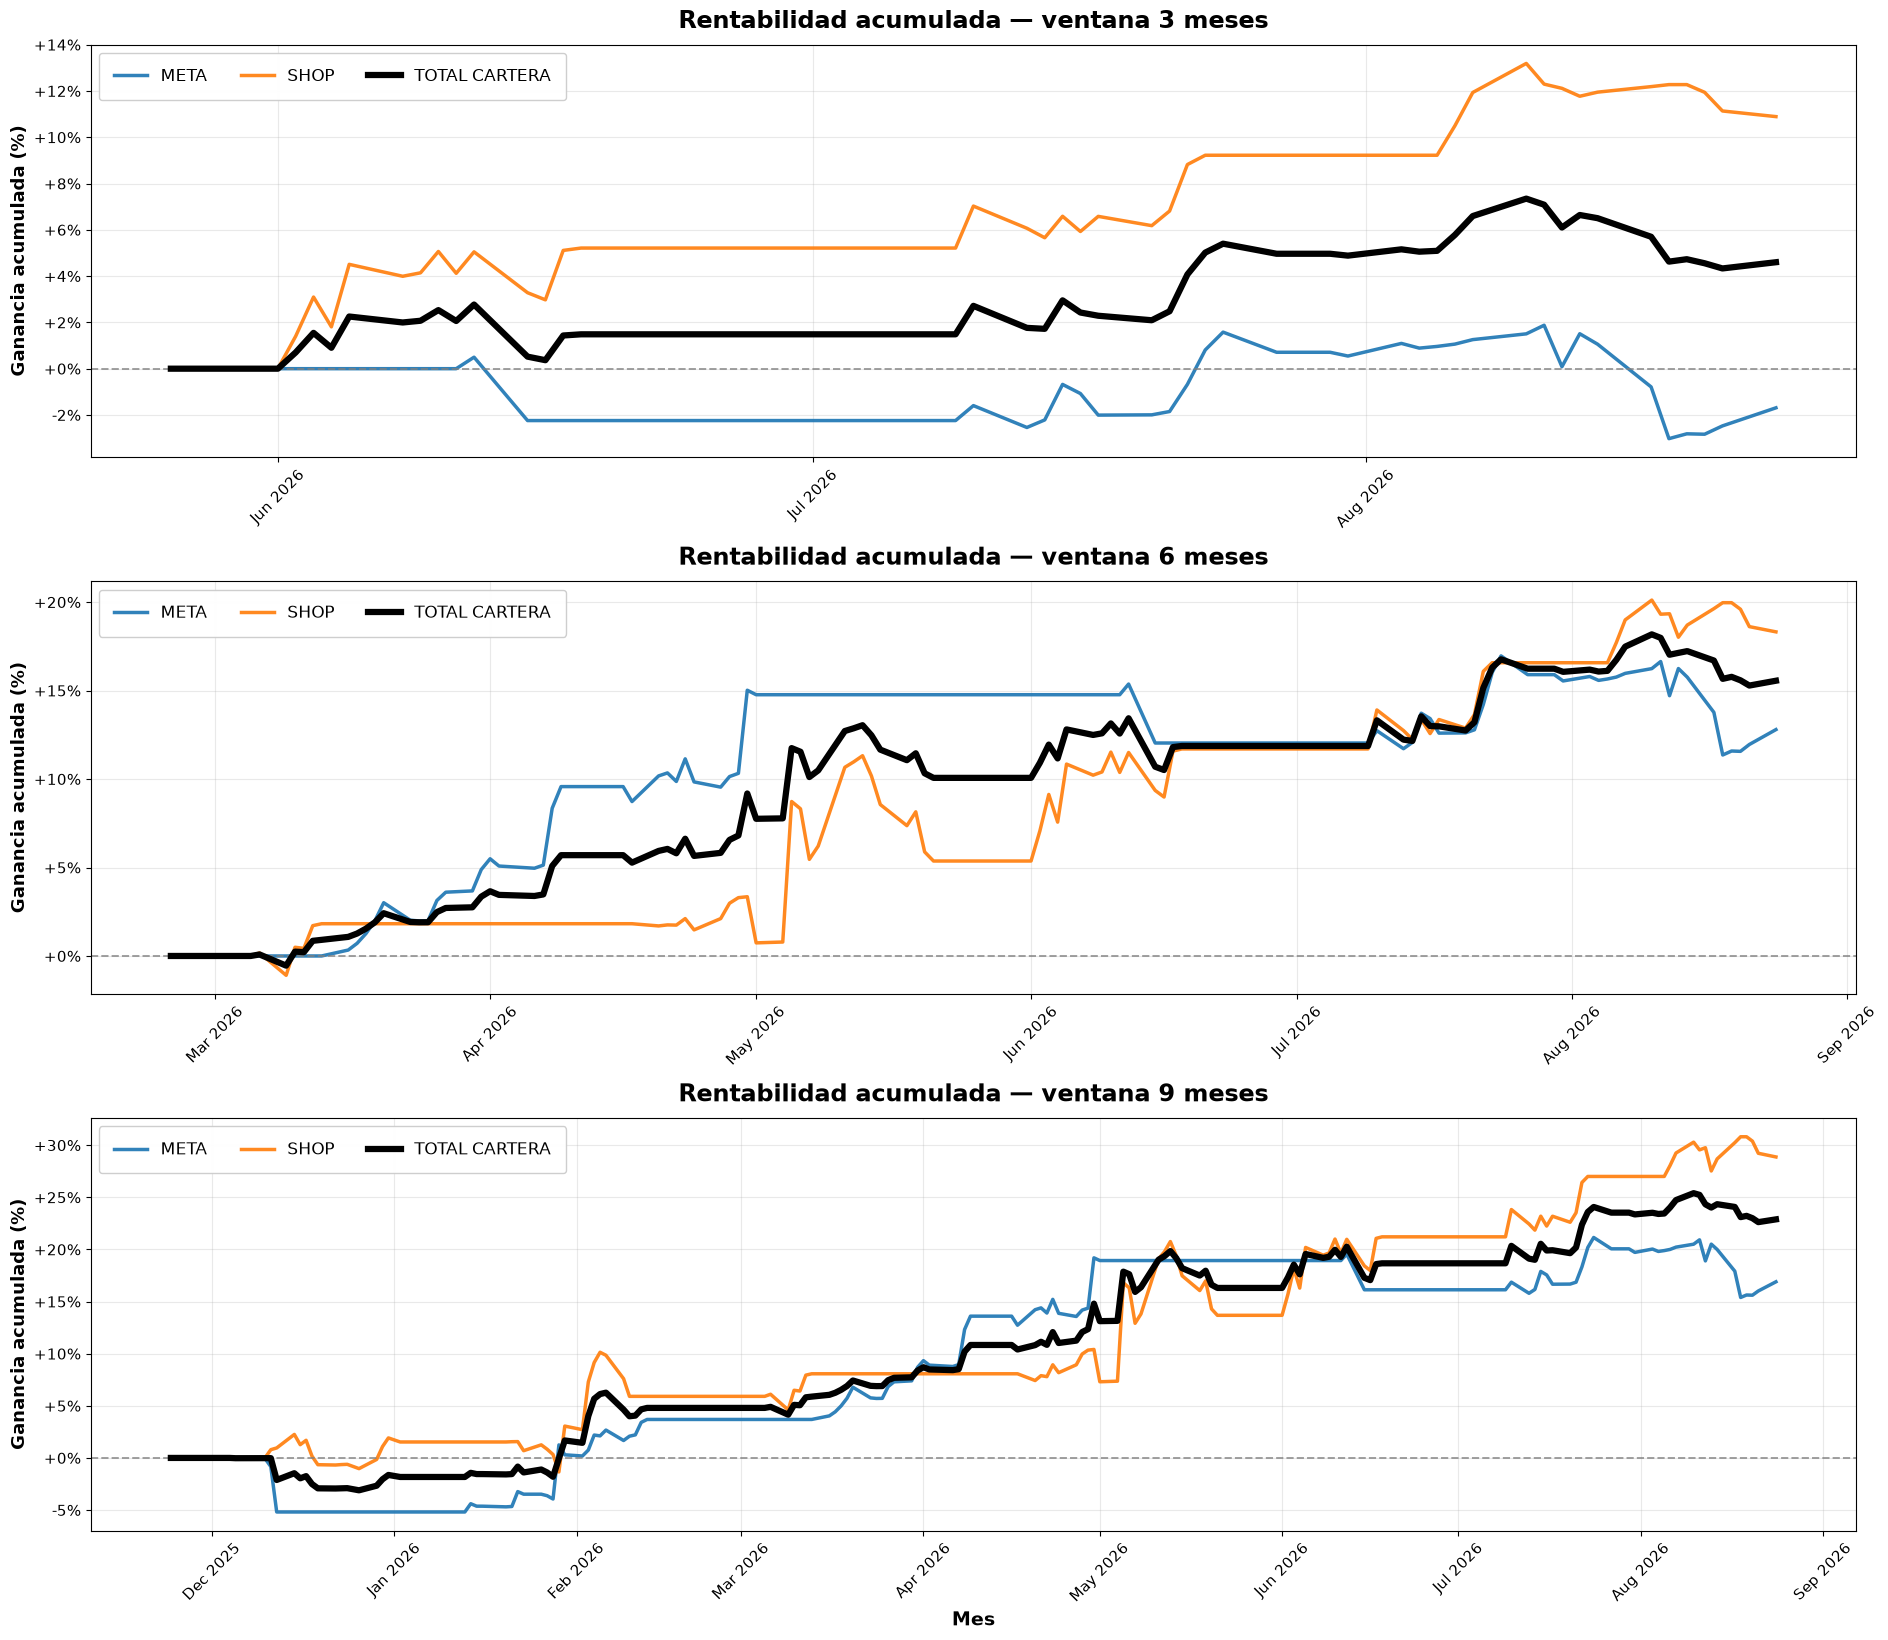

In [7]:
# ================= GRÁFICO RESUMEN DE RENTABILIDAD =================
# Todos los activos y la cartera total parten de 0 %, lo que permite comparar
# rentabilidades aunque los capitales iniciales asignados sean diferentes.
n = len(VENTANAS_MESES)
fig, axes = plt.subplots(n, 1, figsize=(19, max(7, 5.5 * n)), squeeze=False)

# BUCLE DE SUBGRÁFICAS: empareja cada eje con una ventana temporal activa.
for ax, meses in zip(axes[:, 0], VENTANAS_MESES):

    # BUCLE DE ACTIVOS: transforma cada curva monetaria en rentabilidad porcentual.
    for ticker in tickers:
        eq = resultados[meses][ticker]['Equity']['Equity']
        rentabilidad = (eq / capitales[ticker] - 1) * 100
        ax.plot(
            rentabilidad.index, rentabilidad, color=colores[ticker],
            lw=2.5, alpha=.92, label=ticker
        )

    # La línea negra representa el rendimiento agregado de toda la cartera.
    capital_total_inicial = sum(capitales.values())
    total = resultados[meses]['TOTAL CARTERA']['Equity']['Equity']
    rentabilidad_total = (total / capital_total_inicial - 1) * 100
    ax.plot(
        rentabilidad_total.index, rentabilidad_total,
        color='black', lw=4.5, label='TOTAL CARTERA', zorder=6
    )

    # Formato individual de cada subgráfica.
    ax.axhline(0, color='gray', ls='--', lw=1.4, alpha=.75)
    ax.set_title(
        f'Rentabilidad acumulada — ventana {meses} meses',
        fontsize=17, fontweight='bold', pad=12
    )
    ax.set_ylabel('Ganancia acumulada (%)', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0f}%'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.legend(
        loc='best', ncol=min(4, len(tickers) + 1),
        fontsize=12, framealpha=.96, borderpad=.9
    )
    ax.tick_params(axis='both', labelsize=11)
    ax.tick_params(axis='x', rotation=45)

# Etiqueta inferior compartida y exportación del resumen completo.
axes[-1, 0].set_xlabel('Mes', fontsize=14, fontweight='bold')
plt.tight_layout()
display(fig)
plt.close(fig)

## Interpretación y límites

- `FECHA_FIN_VENTANA` es el extremo final solicitado. Si no existe cotización exactamente ese día, la simulación utiliza la última sesión común anterior.
- Para una ventana de *n* meses se resta `relativedelta(months=n)` desde la sesión final común; la primera sesión real será la primera cotización disponible desde esa fecha objetivo.
- Cada activo utiliza únicamente el capital asignado en `ACTIVOS`; no se rebalancea ni transfiere dinero entre valores.
- Un activo puede tener una posición abierta al mismo tiempo que los demás.
- El resumen porcentual divide cada curva por su propio capital inicial. La línea negra divide el total por la suma de todos los capitales asignados.
- Los rendimientos se calculan en la moneda local de cada cotización. La fila total no incorpora fluctuaciones de divisa.
- El modelo admite fracciones teóricas de acciones; no comprueba lotes mínimos, margen ni disponibilidad para cortos.
- Los resultados históricos no garantizan rendimientos futuros.